# Stage 7 — Priority Ranking Engine
## PS1: Parking-Induced Congestion — Bengaluru



This is the stage that directly answers the third verb in the problem
statement: *"enable targeted enforcement."* Detection (Stage 2) and
quantification (Stage 6) are done — this stage turns those into a single
ranked, actionable list.

```
Priority = Congestion Impact Index × Persistence × Time Risk (corrected)
```

This notebook covers:
1. Setup
2. Why a normalization step is needed before multiplying
3. Compute the Priority Score
4. Validate the formula's behaviour
5. Final ranking + visualization
6. Two action lists — maintain vs reallocate
7. Save + summary


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

cs = pd.read_csv("/content/drive/MyDrive/gridlock_flipkart/cluster_summary_with_impact.csv")
print(f"Loaded {cs.shape[0]} clusters, {cs.shape[1]} columns")
cs[["cluster_id", "top_station", "congestion_impact_index",
   "persistence", "time_risk_corrected"]].head()

Loaded 30 clusters, 45 columns


,cluster_id,top_station,congestion_impact_index,persistence,time_risk_corrected
0,29,Upparpet,31.20,1.000000,0.209794
1,7,HSR Layout,26.48,1.000000,0.191354
2,25,City Market,30.50,0.988095,0.191489
3,11,Malleshwaram,24.45,0.988095,0.214534
4,27,Upparpet,27.70,0.988095,0.219395


## 1. Why normalization is needed before multiplying

Checking the raw ranges of the three components going into Priority:

| Component | Range |
|---|---|
| `congestion_impact_index` | 15.46 – 53.42 |
| `persistence` | 0.70 – 1.00 |
| `time_risk_corrected` | 0.18 – 0.36 |

`persistence` only spans 0.70–1.0 — multiplying directly would barely move
the result (every cluster gets multiplied by something close to 1),
collapsing most of the discriminating signal Stage 4 spent effort building.
Same problem with `time_risk_corrected`, which spans a narrow 0.18–0.36 band.

**Fix:** min-max normalize `persistence` and `time_risk_corrected` to 0–1
*relative to this cluster set* before multiplying, the same approach used
for the Impact Index components in Stage 6. The Impact Index itself is
already 0–100, so it's rescaled to 0–1 too, keeping all three components on
equal footing before combination.


In [ ]:
from sklearn.preprocessing import MinMaxScaler

PRIORITY_COMPONENTS = ["congestion_impact_index", "persistence", "time_risk_corrected"]

scaler = MinMaxScaler()
norm_priority = pd.DataFrame(
    scaler.fit_transform(cs[PRIORITY_COMPONENTS]),
    columns=[f"{c}_pnorm" for c in PRIORITY_COMPONENTS],
    index=cs.index
)

cs = pd.concat([cs, norm_priority], axis=1)
cs[[f"{c}_pnorm" for c in PRIORITY_COMPONENTS]].describe()

,congestion_impact_index_pnorm,persistence_pnorm,time_risk_corrected_pnorm
count,30.000000,30.000000,30.000000
mean,0.445592,0.834667,0.268729
std,0.232305,0.242682,0.209780
min,0.000000,0.000000,0.000000
25%,0.282798,0.840000,0.139552
50%,0.399895,0.920000,0.236720
75%,0.591675,0.960000,0.316189
max,1.000000,1.000000,1.000000


## 2. Compute the Priority Score

```
Priority = impact_norm * persistence_norm * time_risk_norm
```

Multiplicative (not additive) by design — a cluster needs to score
reasonably on **all three** dimensions to rank highly. A cluster with a huge
impact score but near-zero persistence (a one-off event) shouldn't outrank
a cluster that's moderately bad on all three, consistently. Multiplication
enforces that; addition would let one strong component compensate for two
weak ones.

A small epsilon (0.01) is added to each normalized component before
multiplying, so a cluster that happens to be the literal minimum on any one
dimension (normalized to exactly 0) doesn't get a priority score of zero
regardless of how it scores on the other two.


In [ ]:
EPSILON = 0.01

cs["priority_score"] = (
    (cs["congestion_impact_index_pnorm"] + EPSILON)
    * (cs["persistence_pnorm"] + EPSILON)
    * (cs["time_risk_corrected_pnorm"] + EPSILON)
)

# Rescale final score to a readable 0-100 range
cs["priority_score"] = (
    (cs["priority_score"] - cs["priority_score"].min())
    / (cs["priority_score"].max() - cs["priority_score"].min())
    * 100
).round(2)

priority_ranked = cs[["cluster_id", "top_station", "size",
                      "congestion_impact_index", "persistence",
                      "time_risk_corrected", "hotspot_type",
                      "priority_score"]]\
    .sort_values("priority_score", ascending=False)

priority_ranked

,cluster_id,top_station,size,congestion_impact_index,persistence,time_risk_corrected,hotspot_type,priority_score
21,28,Upparpet,1972,47.42,0.928571,0.359805,Sporadic,100.00
24,18,Rajajinagar,1721,41.08,0.964286,0.237354,Recurring,31.24
7,21,Malleshwaram,3436,46.26,0.988095,0.220385,Structural,29.72
12,23,Shivajinagar,2514,32.01,0.976190,0.247585,Recurring,24.71
23,3,K.R. Pura,1789,29.15,0.976190,0.260853,Recurring,24.28
5,20,Malleshwaram,4068,29.81,0.988095,0.234837,Structural,18.44
6,24,Shivajinagar,3603,24.67,0.988095,0.261673,Structural,17.38
29,17,Pulikeshinagar(F.Town),1379,22.45,0.940476,0.308639,Sporadic,17.19
20,5,HAL Old Airport,1988,53.42,0.892857,0.206532,Sporadic,16.94
14,19,Halasur,2374,30.86,0.976190,0.219872,Recurring,14.17


## 3. Validate the formula's behaviour

Two checks: does the ranking meaningfully differ from ranking by Impact
Index alone (proving persistence and time risk actually matter), and does
a cluster need to be reasonably strong on all three dimensions to reach the
top — not just dominant on one.


In [ ]:
# Check 1: correlation between Priority and raw Impact Index ranking
from scipy.stats import spearmanr

corr, _ = spearmanr(cs["priority_score"], cs["congestion_impact_index"])
print(f"Spearman correlation: Priority vs Impact Index alone = {corr:.4f}")
print(f"(If this were 1.0, persistence and time_risk would be contributing nothing)")

# Check 2: how many positions did each cluster move, comparing the two rankings
cs["impact_rank"] = cs["congestion_impact_index"].rank(ascending=False)
cs["priority_rank"] = cs["priority_score"].rank(ascending=False)
cs["rank_shift"] = cs["impact_rank"] - cs["priority_rank"]

shift_table = cs[["cluster_id", "top_station", "impact_rank",
                  "priority_rank", "rank_shift"]]\
    .sort_values("rank_shift", key=abs, ascending=False)

print(f"\nClusters with the biggest rank shift (impact-only rank vs final priority rank):")
shift_table.head(8)

Spearman correlation: Priority vs Impact Index alone = 0.2556
(If this were 1.0, persistence and time_risk would be contributing nothing)

Clusters with the biggest rank shift (impact-only rank vs final priority rank):


,cluster_id,top_station,impact_rank,priority_rank,rank_shift
27,26,Upparpet,2.0,28.0,-26.0
18,4,Mahadevapura,6.0,27.0,-21.0
29,17,Pulikeshinagar(F.Town),28.0,8.0,20.0
6,24,Shivajinagar,25.0,7.0,18.0
13,0,Chikkajala,7.0,23.0,-16.0
23,3,K.R. Pura,20.0,5.0,15.0
5,20,Malleshwaram,18.0,6.0,12.0
22,12,Byatarayanapura,8.0,20.0,-12.0


## 4. Final ranking visualization

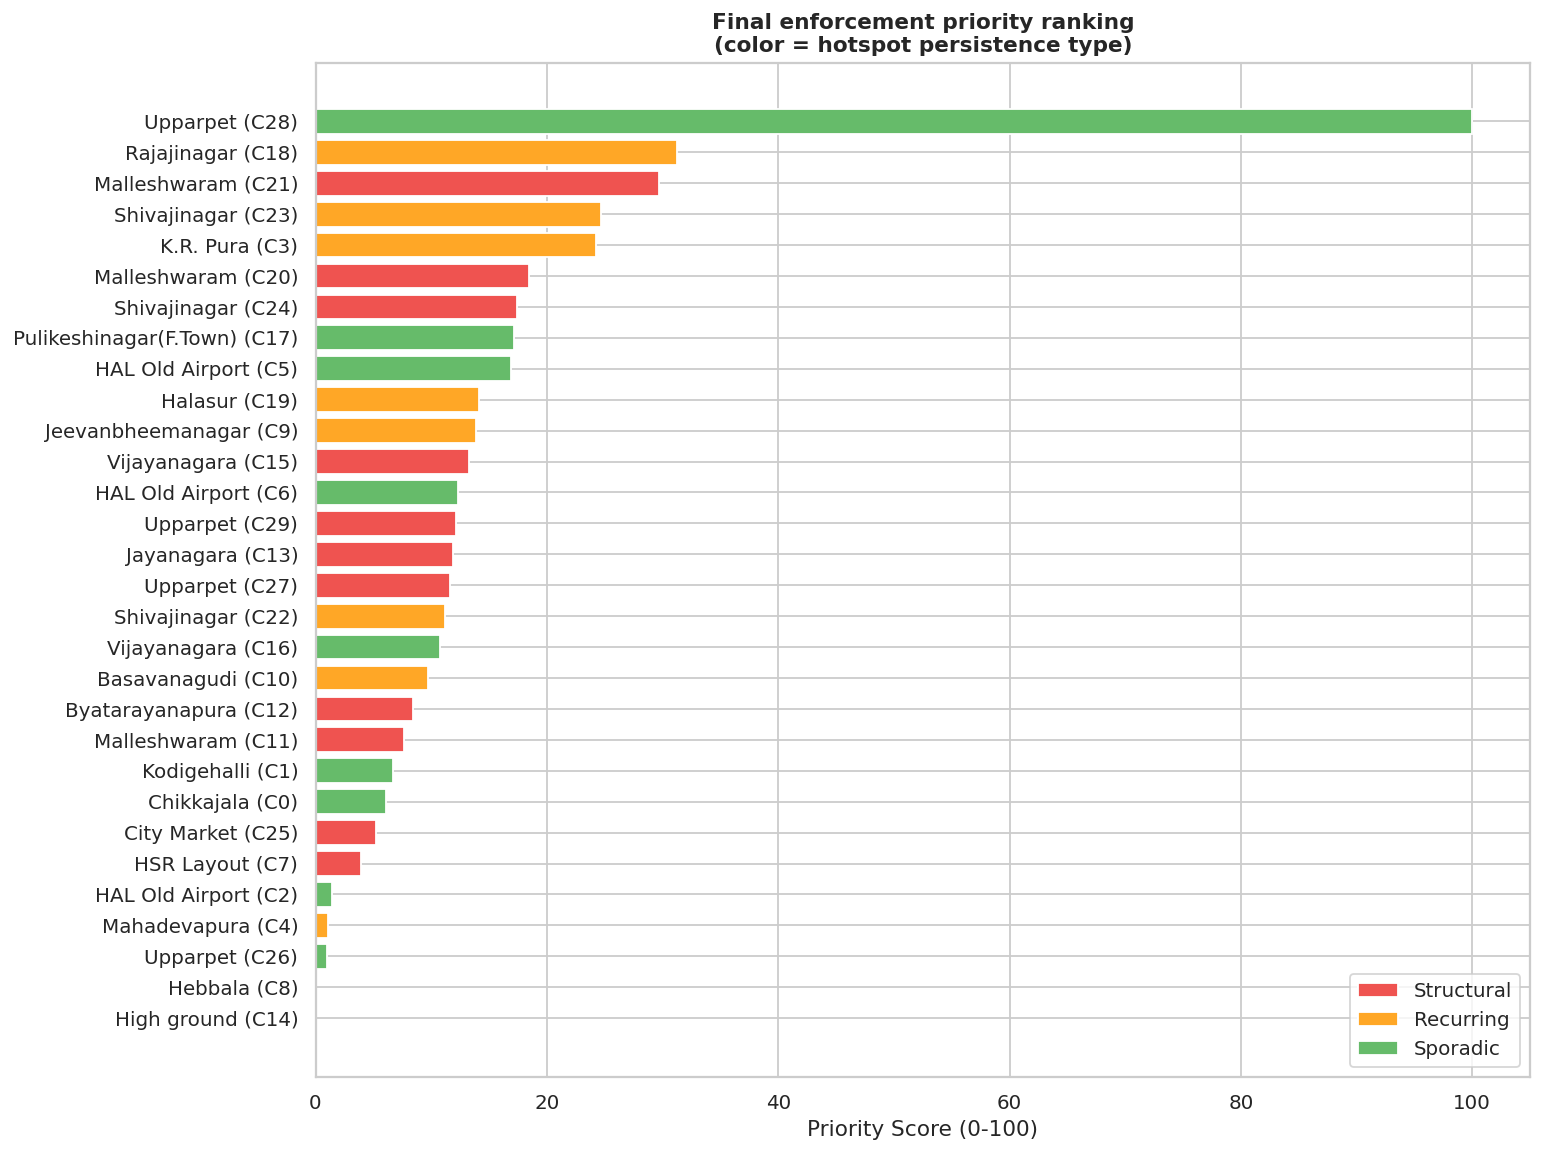

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))

ordered = cs.sort_values("priority_score", ascending=True)
colors_h = {"Structural": "#EF5350", "Recurring": "#FFA726", "Sporadic": "#66BB6A"}
bar_colors = ordered["hotspot_type"].map(colors_h)

ax.barh(ordered["top_station"] + " (C" + ordered["cluster_id"].astype(str) + ")",
        ordered["priority_score"], color=bar_colors)
ax.set_xlabel("Priority Score (0-100)")
ax.set_title("Final enforcement priority ranking\n"
             "(color = hotspot persistence type)", fontweight="bold")

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=v, label=k) for k, v in colors_h.items()]
ax.legend(handles=legend_els, loc="lower right")

plt.tight_layout()
plt.savefig("s7_priority_ranking.png")
plt.show()

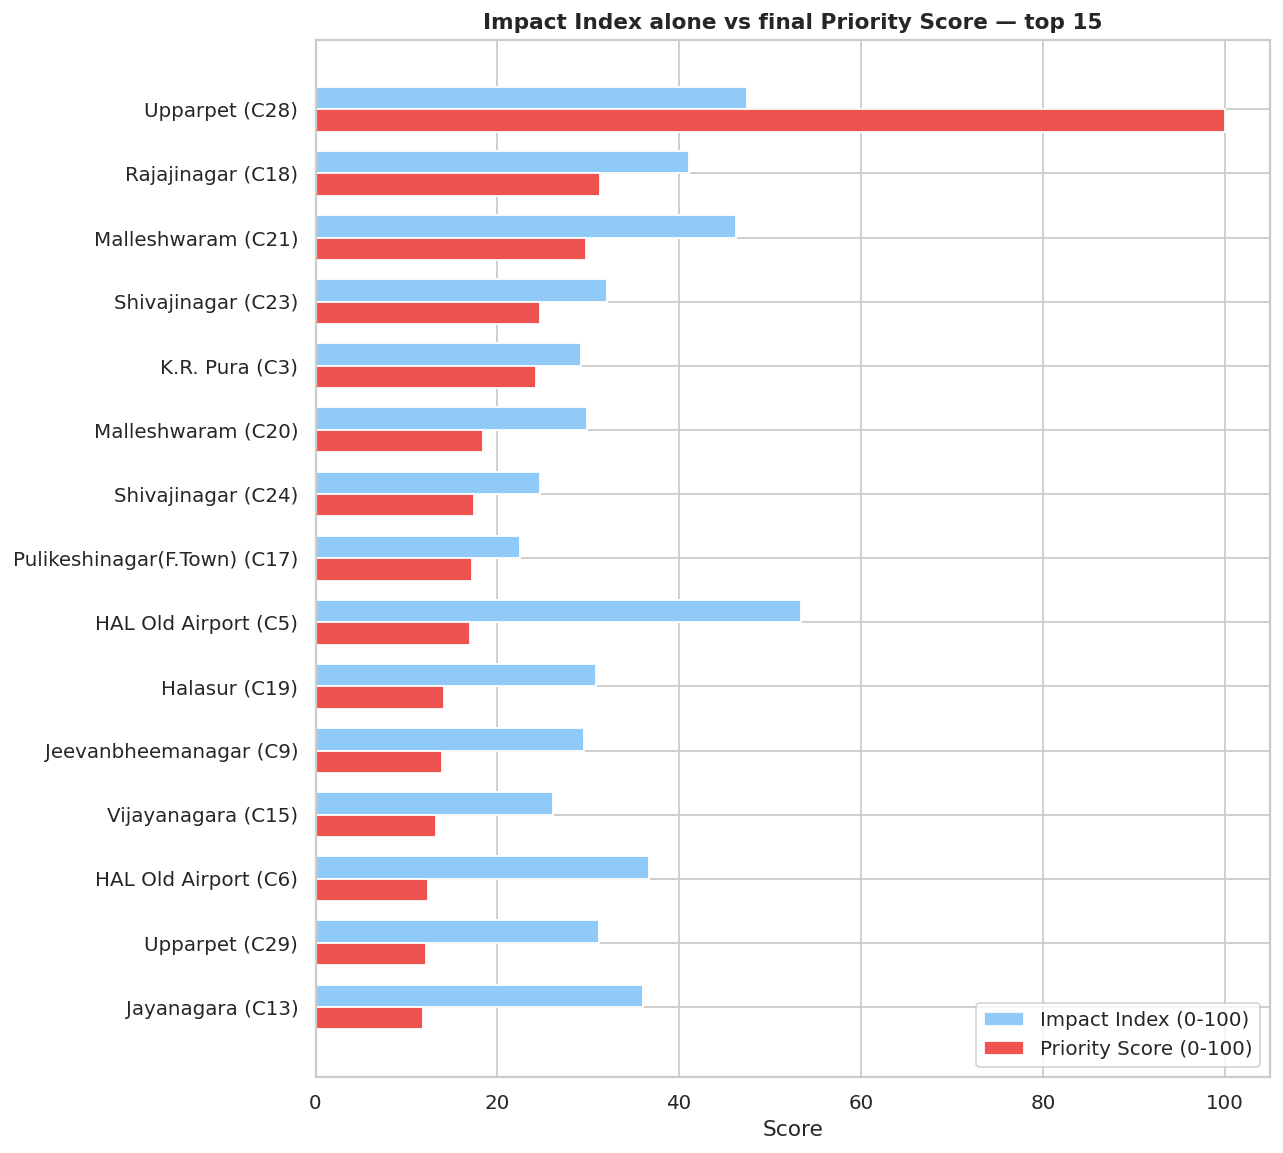

In [ ]:
# Side-by-side: Impact-only rank vs Priority rank, top 15
fig, ax = plt.subplots(figsize=(10, 9))

top15 = cs.sort_values("priority_score", ascending=False).head(15).copy()
top15_labels = top15["top_station"] + " (C" + top15["cluster_id"].astype(str) + ")"

x = np.arange(len(top15))
width = 0.35

ax.barh(x - width/2, top15.set_index(top15_labels)["congestion_impact_index"],
        height=width, label="Impact Index (0-100)", color="#90CAF9")
ax.barh(x + width/2, top15.set_index(top15_labels)["priority_score"],
        height=width, label="Priority Score (0-100)", color="#EF5350")

ax.set_yticks(x)
ax.set_yticklabels(top15_labels)
ax.invert_yaxis()
ax.set_xlabel("Score")
ax.set_title("Impact Index alone vs final Priority Score — top 15", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("s7_impact_vs_priority.png")
plt.show()

## 5. Two action lists

The actual operational deliverable. Per the Stage 3b framing: not just "go
where violations already are," but a split between zones to maintain
current (likely night-heavy) patrol on, and zones that show real risk but
are under-covered during the day.


In [ ]:
print("="*70)
print("LIST 1 — TOP PRIORITY ENFORCEMENT ZONES (overall ranking)")
print("="*70)
list1 = priority_ranked.head(10)
print(list1.to_string(index=False))

print("\n" + "="*70)
print("LIST 2 — HIGH PRIORITY + HIGH BLIND-SPOT-RISK (daytime reallocation)")
print("="*70)
list2 = cs[cs["priority_score"] >= cs["priority_score"].median()]\
    .sort_values("blind_spot_risk", ascending=False)\
    [["cluster_id", "top_station", "priority_score",
     "blind_spot_risk", "enforcement_coverage_score"]]\
    .head(10)
print(list2.to_string(index=False))

LIST 1 — TOP PRIORITY ENFORCEMENT ZONES (overall ranking)
 cluster_id            top_station  size  congestion_impact_index  persistence  time_risk_corrected hotspot_type  priority_score
         28               Upparpet  1972                    47.42     0.928571             0.359805     Sporadic          100.00
         18            Rajajinagar  1721                    41.08     0.964286             0.237354    Recurring           31.24
         21           Malleshwaram  3436                    46.26     0.988095             0.220385   Structural           29.72
         23           Shivajinagar  2514                    32.01     0.976190             0.247585    Recurring           24.71
          3              K.R. Pura  1789                    29.15     0.976190             0.260853    Recurring           24.28
         20           Malleshwaram  4068                    29.81     0.988095             0.234837   Structural           18.44
         24           Shivajinagar  360